# SuperPoint and SuperGlue: PyTorch vs JAX vs JavaScript Comparison

In [1]:

import torch
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import json
import subprocess
import random
from PIL import Image
import sys

# Add the repository root to the path to import models
sys.path.append('..')
sys.path.append('../LightGlue')

from superpoint_jax.model.superpoint_torch import SuperPointTorch
from superpoint_jax.model.superpoint_jax import SuperPointJAX
from superpoint_jax.model.superglue_torch import SuperGlue as SuperGlueTorch
from superpoint_jax.model.superglue_jax import SuperGlueJAX
from superpoint_jax.utils import convert_superpoint_weights, convert_superglue_weights
from flax import nnx
from lightglue import LightGlue

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Load Models

In [2]:

# SuperPoint Models
sp_torch = SuperPointTorch(max_num_keypoints=1024).to(device)
sp_torch.load_state_dict(torch.load('../weights/superpoint_torch.pth', map_location=device))
sp_torch.eval()

sp_jax = SuperPointJAX(max_num_keypoints=1024, rngs=nnx.Rngs(0))
sp_jax = convert_superpoint_weights(sp_torch, sp_jax)

# SuperGlue Models
sg_torch = SuperGlueTorch({'weights': 'indoor'}).to(device)
sg_torch.eval()

sg_jax = SuperGlueJAX(rngs=nnx.Rngs(0))
sg_jax = convert_superglue_weights(sg_torch, sg_jax)

# LightGlue Model
lg_matcher = LightGlue(features='superpoint').to(device)
lg_matcher.eval()

print("All models loaded and converted.")


Loaded SuperGlue model ("indoor" weights)


All models loaded and converted.


## Helper Functions

In [3]:

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {path}")
    img_float = img.astype(np.float32) / 255.0
    return img, img_float

def run_pytorch(img0_float, img1_float):
    with torch.no_grad():
        inp0 = torch.from_numpy(img0_float).unsqueeze(0).unsqueeze(0).to(device)
        inp1 = torch.from_numpy(img1_float).unsqueeze(0).unsqueeze(0).to(device)
        
        out0 = sp_torch({'image': inp0})
        out1 = sp_torch({'image': inp1})
        
        data = {
            'image0': inp0,
            'keypoints0': out0['keypoints'][0].unsqueeze(0),
            'scores0': out0['keypoint_scores'][0].unsqueeze(0),
            'descriptors0': out0['descriptors'][0].unsqueeze(0).transpose(1, 2),
            'image1': inp1,
            'keypoints1': out1['keypoints'][0].unsqueeze(0),
            'scores1': out1['keypoint_scores'][0].unsqueeze(0),
            'descriptors1': out1['descriptors'][0].unsqueeze(0).transpose(1, 2),
        }
        
        res = sg_torch(data)
        return {
            'kpts0': data['keypoints0'][0].cpu().numpy(),
            'kpts1': data['keypoints1'][0].cpu().numpy(),
            'matches0': res['matches0'][0].cpu().numpy(),
            'matching_scores0': res['matching_scores0'][0].cpu().numpy(),
            'attentions': res['attentions']
        }

def run_lightglue(img0_float, img1_float):
    with torch.no_grad():
        inp0 = torch.from_numpy(img0_float).unsqueeze(0).unsqueeze(0).to(device)
        inp1 = torch.from_numpy(img1_float).unsqueeze(0).unsqueeze(0).to(device)
        
        out0 = sp_torch({'image': inp0})
        out1 = sp_torch({'image': inp1})
        
        data = {
            'image0': {
                'keypoints': torch.stack(out0['keypoints']),
                'descriptors': torch.stack(out0['descriptors']),
                'image_size': torch.tensor([[inp0.shape[3], inp0.shape[2]]], device=device).float()
            },
            'image1': {
                'keypoints': torch.stack(out1['keypoints']),
                'descriptors': torch.stack(out1['descriptors']),
                'image_size': torch.tensor([[inp1.shape[3], inp1.shape[2]]], device=device).float()
            }
        }
        
        res = lg_matcher(data)
        return {
            'kpts0': data['image0']['keypoints'][0].cpu().numpy(),
            'kpts1': data['image1']['keypoints'][0].cpu().numpy(),
            'matches0': res['matches0'][0].cpu().numpy(),
            'matching_scores0': res['matching_scores0'][0].cpu().numpy(),
        }

def run_jax(img0_float, img1_float):
    inp0 = jnp.array(img0_float)[None, ..., None]
    inp1 = jnp.array(img1_float)[None, ..., None]
    
    out0 = sp_jax(inp0, training=False)
    out1 = sp_jax(inp1, training=False)
    
    v0 = int(out0['valid_counts'][0])
    v1 = int(out1['valid_counts'][0])
    
    data = {
        'image0_shape': (1, 1, *img0_float.shape),
        'keypoints0': out0['keypoints'][:, :v0],
        'scores0': out0['scores'][:, :v0],
        'descriptors0': out0['descriptors'][:, :v0].transpose(0, 2, 1),
        'image1_shape': (1, 1, *img1_float.shape),
        'keypoints1': out1['keypoints'][:, :v1],
        'scores1': out1['scores'][:, :v1],
        'descriptors1': out1['descriptors'][:, :v1].transpose(0, 2, 1),
    }
    
    res = sg_jax(data, training=False)
    return {
        'kpts0': np.array(data['keypoints0'][0]),
        'kpts1': np.array(data['keypoints1'][0]),
        'matches0': np.array(res['matches0'][0]),
        'matching_scores0': np.array(res['matching_scores0'][0]),
        'attentions': res['attentions']
    }

def visualize_pair(img0, img1, res, title_prefix):
    kpts0 = res['kpts0']
    kpts1 = res['kpts1']
    matches0 = res['matches0']
    mscores0 = res['matching_scores0']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{title_prefix} Comparison", fontsize=16)
    
    # Row 1: SuperPoint keypoints
    axes[0, 0].imshow(img0, cmap='gray')
    axes[0, 0].scatter(kpts0[:, 0], kpts0[:, 1], s=2, c='lime')
    axes[0, 0].set_title("Image A Keypoints")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img1, cmap='gray')
    axes[0, 1].scatter(kpts1[:, 0], kpts1[:, 1], s=2, c='lime')
    axes[0, 1].set_title("Image B Keypoints")
    axes[0, 1].axis('off')
    
    # Row 2: Cross-Attention or Matches
    if 'attentions' in res and (matches0 > -1).any():
        valid_indices = np.where(matches0 > -1)[0]
        best_idx = valid_indices[np.argmax(mscores0[valid_indices])]
        matched_idx = matches0[best_idx]
        
        # Get cross attention from layer 5 (index 5)
        # Note: In our implementation layer_names = ['self', 'cross'] * 9
        # index 5 is the 3rd 'cross' layer
        attn_layer = res['attentions'][5] 
        # prob0 is [B, num_heads, N0, N1]
        # We'll average over heads and take best_idx
        if torch.is_tensor(attn_layer['prob0']):
            attn_weights = attn_layer['prob0'][0].mean(0)[best_idx].cpu().numpy()
        else:
            attn_weights = np.array(attn_layer['prob0'][0].mean(0)[best_idx])
            
        # Draw on Image A
        axes[1, 0].imshow(img0, cmap='gray')
        q = kpts0[best_idx]
        axes[1, 0].scatter(q[0], q[1], s=40, c='cyan', edgecolors='black')
        axes[1, 0].set_title(f"Cross-Attn from A (kp {best_idx})")
        axes[1, 0].axis('off')

        # To show lines across images, we'll create a composite image
        h, w = img0.shape
        composite = np.zeros((h, w * 2 + 10), dtype=np.uint8)
        composite[:, :w] = img0
        composite[:, w+10:] = img1
        composite = cv2.cvtColor(composite, cv2.COLOR_GRAY2BGR)
        
        q_pos = (int(q[0]), int(q[1]))
        max_attn = attn_weights.max()
        for i, weight in enumerate(attn_weights):
            if weight > 0.05 * max_attn:
                p_target = kpts1[i]
                t_pos = (int(p_target[0] + w + 10), int(p_target[1]))
                alpha = min(1.0, weight / max_attn)
                color = (0, int(255 * alpha), int(255 * alpha)) # Cyan-ish
                cv2.line(composite, q_pos, t_pos, color, 1)
        
        cv2.circle(composite, q_pos, 4, (255, 255, 0), -1) # Cyan query
        axes[1, 1].imshow(cv2.cvtColor(composite, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title("Cross-Attention Lines")
        axes[1, 1].axis('off')
    elif (matches0 > -1).any():
        # Just show matches for LightGlue or if attentions missing
        h, w = img0.shape
        composite = np.zeros((h, w * 2 + 10), dtype=np.uint8)
        composite[:, :w] = img0
        composite[:, w+10:] = img1
        composite = cv2.cvtColor(composite, cv2.COLOR_GRAY2BGR)
        
        valid_indices = np.where(matches0 > -1)[0]
        for idx in valid_indices:
            q_pos = (int(kpts0[idx][0]), int(kpts0[idx][1]))
            t_pos = (int(kpts1[matches0[idx]][0] + w + 10), int(kpts1[matches0[idx]][1]))
            cv2.line(composite, q_pos, t_pos, (0, 255, 0), 1)
            
        axes[1, 0].imshow(img0, cmap='gray')
        axes[1, 0].set_title("Matches on Image A")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(cv2.cvtColor(composite, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title(f"All {len(valid_indices)} Matches")
        axes[1, 1].axis('off')
    else:
        axes[1, 0].text(0.5, 0.5, "No matches found", ha='center')
        axes[1, 1].text(0.5, 0.5, "No matches found", ha='center')
        axes[1, 0].axis('off')
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()


## 10-Pair Evaluation Loop

Reference frame: frame_0460.png (idx 460)

--- [Pair 1] Comparing frame_0100.png vs frame_0125.png (offset +25) ---
Running JAX...


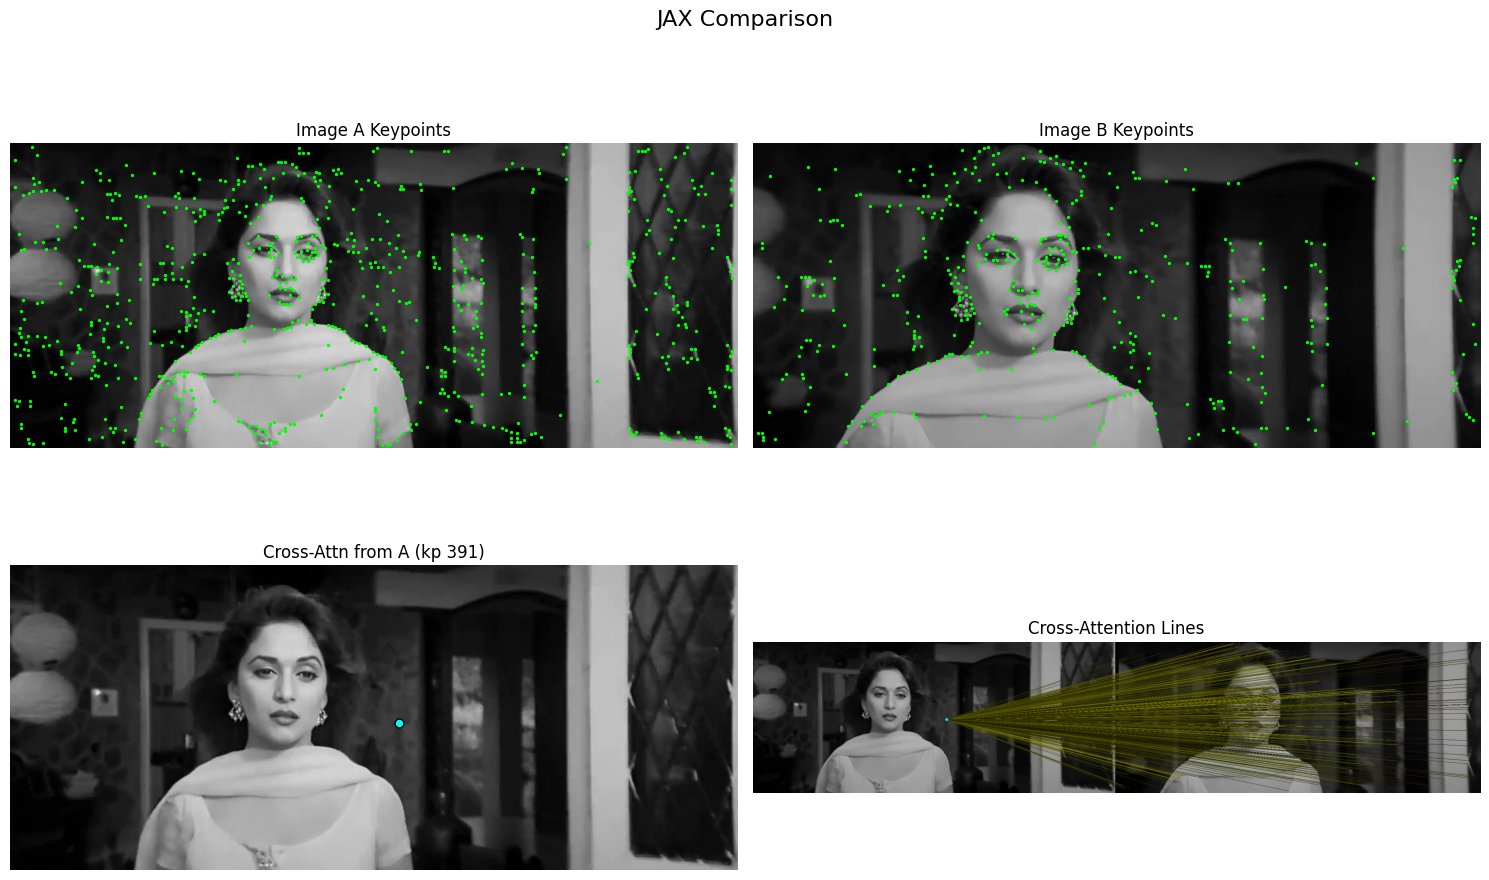

Running PyTorch...


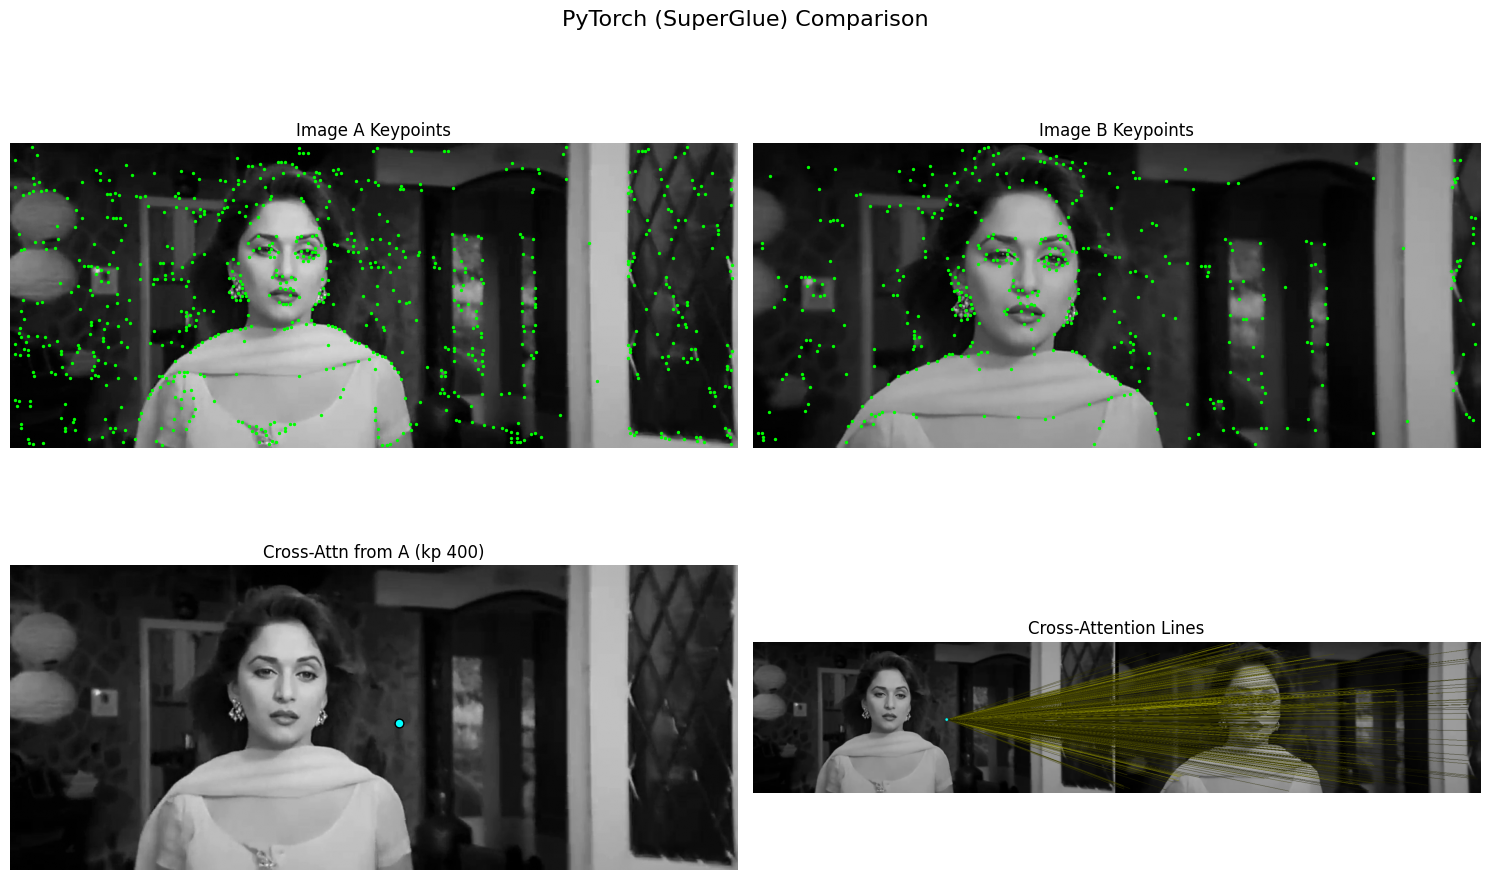

Running LightGlue...


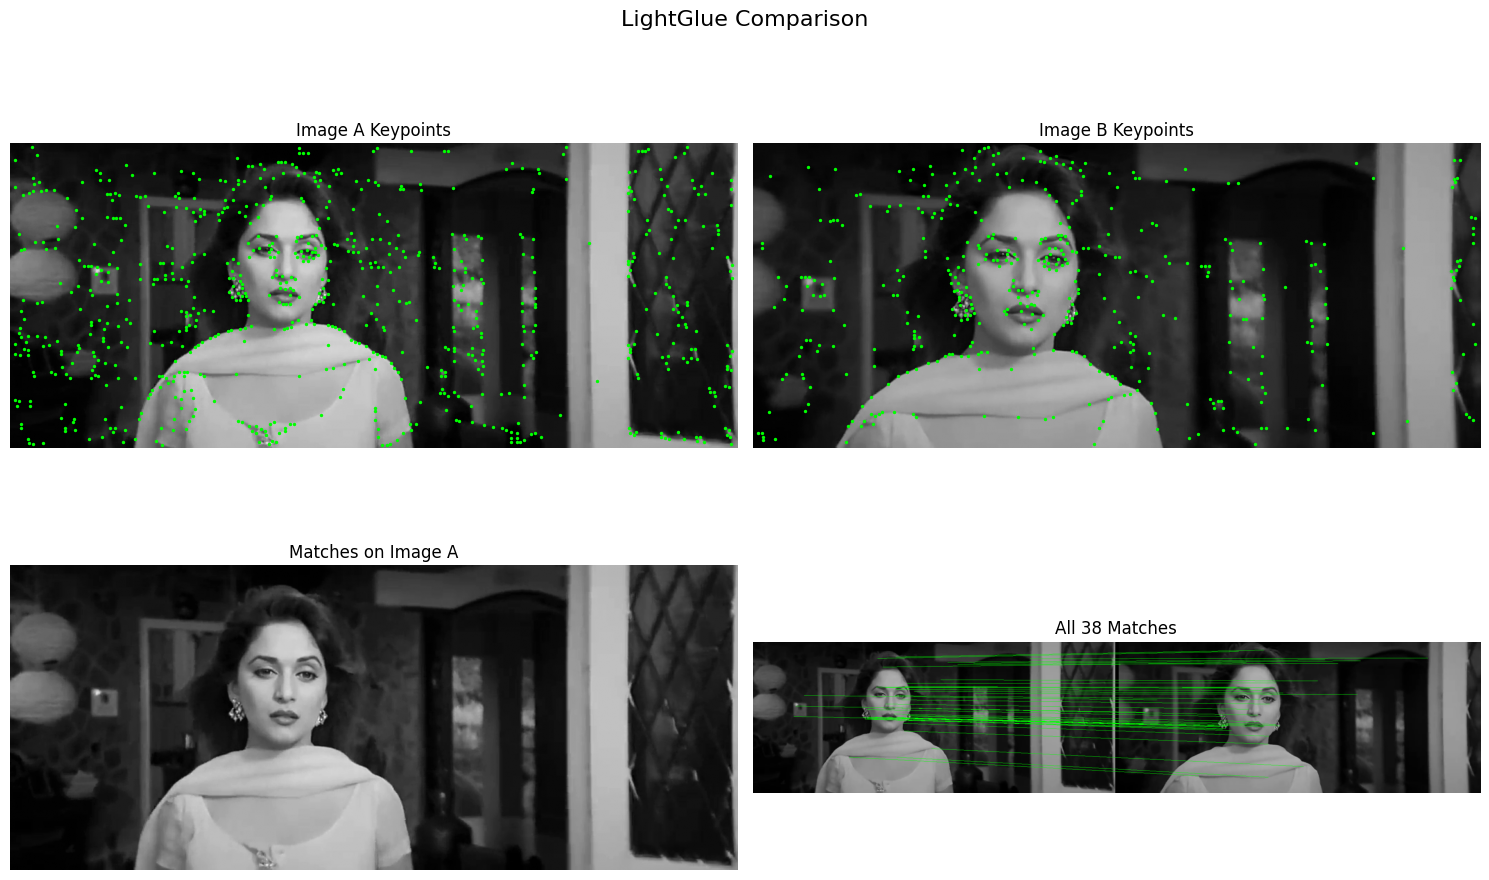

Running JavaScript...
════════════════════════════════════════════════════════════
  SuperGlue.js — Feature Matching via Safetensors Weights
════════════════════════════════════════════════════════════

📦 Loading SuperPoint ONNX model...
   SuperPoint loaded in 66ms

⚡ Running SuperPoint on image 1...


   Image 1: 1024 keypoints (2028ms)

⚡ Running SuperPoint on image 2...


   Image 2: 467 keypoints (1911ms)

🔗 Loading SuperGlue (indoor) weights...
   Loaded 339 tensors from safetensors
   Weights loaded in 83ms
   bin_score: 2.3457

🔗 Running SuperGlue matching...


   GNN: 18 layers complete        


   Matching: 145815ms

────────────────────────────────────────────────────────────
📊 Results Summary
────────────────────────────────────────────────────────────
   Image 1 keypoints: 1024
   Image 2 keypoints: 467
   Matches found:     22
   Match score range: [0.2061, 0.9952]
   Mean match score:  0.3247

   Top 10 matches:
     #   kp1_x   kp1_y   kp2_x   kp2_y     score
   ─────────────────────────────────────────────
     1     718       9     169      90  0.995248
     2     741     245     735     308  0.378290
     3     839     223    1012     197  0.370150
     4     754     235     643     418  0.364665
     5     393     293     285     304  0.361584
     6     829     148    1036     106  0.339863
     7     684      76     678     382  0.337731
     8    1043      40    1012      24  0.337546
     9     812     181    1049     123  0.317567
    10     681     141     671     371  0.312732

🎨 Generating Attention Visualization for match 872 <-> 22 (score 0.9952)
   Saved 

   Saved viz_self_B.png
   Saved viz_cross_A.png


   Saved viz_cross_B.png

🖼️  Creating 2x2 attention summary grid...
   Saved: superglue_2x2_comparison.png

   Total time: 150574ms
════════════════════════════════════════════════════════════


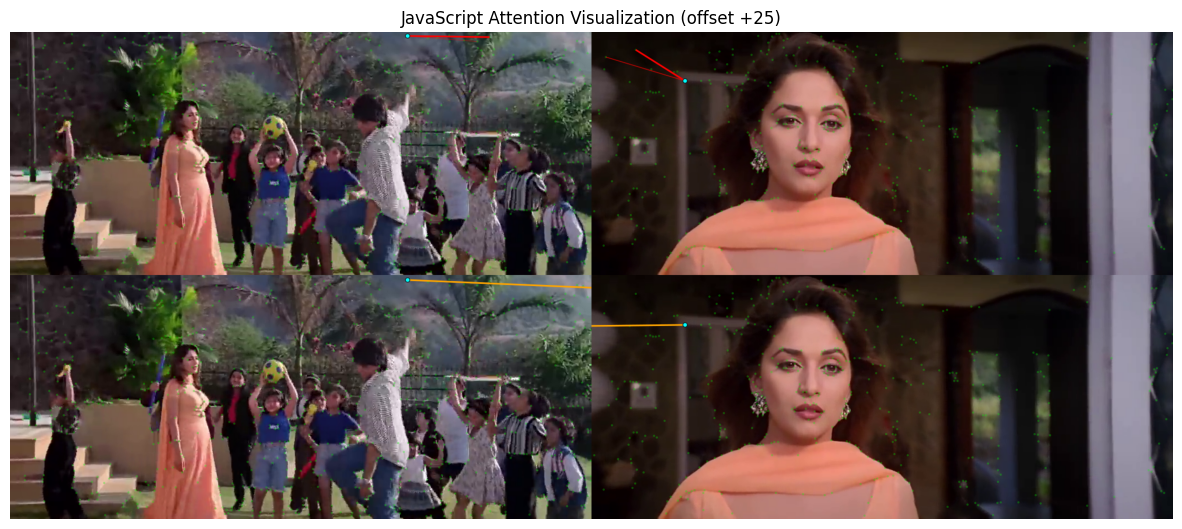

In [4]:

dataset_path = 'frames/input_frames/'
frames = sorted([f for f in os.listdir(dataset_path) if f.endswith('.png')])

# Select random reference frame
ref_idx = random.randint(0, len(frames) - 101)
ref_frame_path = os.path.join(dataset_path, frames[ref_idx])
img_ref, img_ref_float = load_image(ref_frame_path)

print(f"Reference frame: {frames[ref_idx]} (idx {ref_idx})")

# We'll pick a few more "different" sets.
# Instead of just +10, +20 etc from one ref, let's pick 1 different random reference
for i in range(1):
    ref_idx = random.randint(0, len(frames) - 101)
    img_ref, img_ref_float = load_image(os.path.join(dataset_path, frames[ref_idx]))
    
    offset = 25 # Different offset
    target_idx = ref_idx + offset
    target_frame_path = os.path.join(dataset_path, frames[target_idx])
    img_target, img_target_float = load_image(target_frame_path)
    
    print(f"\n--- [Pair {i+1}] Comparing {frames[ref_idx]} vs {frames[target_idx]} (offset +{offset}) ---")
    
    # JAX Backend
    print("Running JAX...")
    res_jax = run_jax(img_ref_float, img_target_float)
    visualize_pair(img_ref, img_target, res_jax, "JAX")
    
    # PyTorch Backend
    print("Running PyTorch...")
    res_torch = run_pytorch(img_ref_float, img_target_float)
    visualize_pair(img_ref, img_target, res_torch, "PyTorch (SuperGlue)")
    
    # LightGlue Backend
    print("Running LightGlue...")
    res_light = run_lightglue(img_ref_float, img_target_float)
    visualize_pair(img_ref, img_target, res_light, "LightGlue")

    # JavaScript Backend
    print("Running JavaScript...")
    js_output = f'js_attn_offset_{offset}.png'
    subprocess.run(['node', 'superglue_js.js', 
                    os.path.abspath(ref_frame_path), 
                    os.path.abspath(target_frame_path), 
                    '--visualize-attention', 
                    '--output', f'js_matches_{offset}.png'], 
                   cwd='../jax-js', check=True)
    
    # The JS script produces 'superglue_2x2_comparison.png' when --visualize-attention is used
    # We should rename it or capture it
    js_viz_path = os.path.join('../jax-js', 'superglue_2x2_comparison.png')
    if os.path.exists(js_viz_path):
        plt.figure(figsize=(15, 10))
        plt.imshow(Image.open(js_viz_path))
        plt.title(f"JavaScript Attention Visualization (offset +{offset})")
        plt.axis('off')
        plt.show()
        # Rename to avoid overwrite if needed, but here we just display it
